# Decision 4 — Portfolio Construction under Vendor Uncertainty

**Context.** In benchmarked asset management, portfolio construction is a relative rather than absolute decision. Portfolio managers rank issuers within the investable universe and allocate capital subject to benchmark and active-risk constraints:

$$w^P = w^B + x, \qquad \sigma_E^2 = x^\top \Sigma x$$

When physical climate risk enters the process, it is translated into a percentile ranking within the universe, and portfolio inclusion is governed by a threshold rule on that rank.

**Transmission chain.** $X_{iv} \to r_{iv} \to w_{iv} \to \text{portfolio outcome}$, where $X_{iv}$ is the vendor-specific damage ratio for issuer $i$, $r_{iv}$ is its percentile rank within the investable universe, and $w_{iv}$ is the resulting portfolio weight.

**The discontinuity.** The mapping from risk metric to rank ($X \to r$) is continuous. But the mapping from rank to portfolio weight ($r \to w$) is discontinuous at the threshold $T$: a small vendor difference in $X_{iv}$ can shift an issuer across the threshold, producing a discrete change in portfolio weight. This is the portfolio analogue of the IFRS 9 staging discontinuity in Decision 1 — there, the cliff is at the SICR threshold $\tau$ (lifetime PD doubles); here, it is at the rank threshold $T$ (issuer crosses the top-$K\%$ boundary). In both cases, vendor model choice determines which side of the cliff an issuer falls on, and the consequence is a discrete change in the regulated or managed outcome.

**Key question.** How often does vendor disagreement place an issuer on different sides of the rank threshold? How much does this affect active weights, tracking error, and portfolio turnover?

In [38]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

BLUE, RED, GREY, AMBER = '#4878CF', '#E84D0E', '#888888', '#F0A500'

In [39]:
# =============================================================================
# PARAMETERS — edit this cell only
# =============================================================================

# --- Seeds ---
VENDOR_SEED    = 1       # single-vendor display cells
PORTFOLIO_SEED = 42      # governs benchmark weight draws
N_DRAWS        = 2000    # vendor uncertainty simulation (matching D1–D3)

# --- Investable universe ---
N_ISSUERS = 100          # one per CFRF property; must equal number of properties in data

# --- Benchmark weights ---
# 'equal'        : w^B_i = 1/N_ISSUERS for all i
# 'heterogeneous': log-normal draws normalised to sum to 1 (market-cap-weighted proxy)
WEIGHT_MODE = 'heterogeneous'
# Parameters for heterogeneous mode
WEIGHT_LN_MU    = 0.0    # log-normal location; weights are normalised so this only affects dispersion
WEIGHT_LN_SIGMA = 0.8    # dispersion: ~5x range between P5 and P95 weight (typical cap-weighted index)

# --- Portfolio rule ---
# 'exclusion'   : excluded issuers receive weight 0; remainder renormalised
# 'underweight' : excluded issuers receive max(w^B_i - delta, 0); remainder renormalised
RULE  = 'underweight'
DELTA = 0.005            # active underweight applied per flagged issuer

# --- Rank threshold ---
THRESHOLD = 0.90         # issuers at or above this percentile rank are flagged (top 10% riskiest)

# --- Tracking error / covariance ---
# 'none'       : skip TE; report active weight dispersion only
# 'one_factor' : stylised factor model Sigma_ij = sigma^2 * (rho + (1-rho)*I)
COVARIANCE_MODE = 'one_factor'
ASSET_VOL  = 0.20        # annualised asset return volatility (sigma); reasonable equity proxy
FACTOR_RHO = 0.30        # pairwise correlation under one-factor model

# --- Pairwise vendor comparison ---
VENDOR_A = 1
VENDOR_B = 2

# --- Pairwise disagreement simulation ---
N_PAIR = 100             # number of vendor draws used for pairwise analysis (C(100,2)=4950 pairs)

# --- Data ---
DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'

In [40]:
# =============================================================================
# DATA LOADING AND TRIANGULAR DISTRIBUTION FITTING
# =============================================================================

df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
df['property_rank'] = df['property_rank'].astype(int)
n = len(df)

assert n == N_ISSUERS, (
    f"N_ISSUERS={N_ISSUERS} but data has {n} properties — adjust N_ISSUERS in PARAMETERS cell."
)

# Triangular distribution parameters
# mode c = 3*mean - min - max, clipped to [min, max]
tri_a = df['minimum_dr'].values.astype(float)
tri_b = df['maximum_dr'].values.astype(float)
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)

results = pd.DataFrame({
    'property_rank': df['property_rank'],
    'd_min':  tri_a,
    'd_mean': df['mean_dr'].values,
    'd_max':  tri_b,
    'd_mode': tri_c,
})

# Zero-damage properties: tri_a == tri_b == 0 -> point mass at d=0
zero_mask = (tri_b == 0)
print(f"Properties loaded: {n}")
print(f"Zero-damage (d=0 always): {zero_mask.sum()}")
print(f"Non-zero damage (fitted triangular): {(~zero_mask).sum()}")

def triangular_sample(rng, a, b, c):
    """Draw one sample per property from Triangular(a, c, b) using inverse CDF.
    Properties with a==b are treated as point masses at a (zero-damage assets).
    """
    u    = rng.uniform(size=len(a))
    span = np.where(b > a, b - a, 1.0)
    fc   = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u, 0)     * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u, 0) * span * np.maximum(b - c, 0))
    x = np.where(u <= fc, left, right)
    return np.where(b > a, np.clip(x, 0, 1), a)

Properties loaded: 100
Zero-damage (d=0 always): 20
Non-zero damage (fitted triangular): 80


In [41]:
# =============================================================================
# BENCHMARK WEIGHT CONSTRUCTION
# =============================================================================

rng_portfolio = np.random.default_rng(PORTFOLIO_SEED)

if WEIGHT_MODE == 'equal':
    w_bench = np.ones(N_ISSUERS) / N_ISSUERS
elif WEIGHT_MODE == 'heterogeneous':
    raw = rng_portfolio.lognormal(
        mean=WEIGHT_LN_MU, sigma=WEIGHT_LN_SIGMA, size=N_ISSUERS
    )
    w_bench = raw / raw.sum()

print(f"Weight mode: {WEIGHT_MODE}")
print(f"Total benchmark weight: {w_bench.sum():.6f}  (should be 1.0)")
if WEIGHT_MODE == 'heterogeneous':
    gini_num = np.sum(np.abs(w_bench[:, None] - w_bench[None, :]))
    gini = gini_num / (2 * N_ISSUERS * w_bench.sum())
    print(f"Weight min: {w_bench.min():.4f}  max: {w_bench.max():.4f}  Gini: {gini:.4f}")

Weight mode: heterogeneous
Total benchmark weight: 1.000000  (should be 1.0)
Weight min: 0.0018  max: 0.0480  Gini: 0.3269


In [42]:
# =============================================================================
# CORE FUNCTIONS
# =============================================================================

def sample_damage(rng):
    """Draw one damage ratio per issuer from the fitted triangular distributions."""
    return triangular_sample(rng, tri_a, tri_b, tri_c)


def rank_issuers(d_array):
    """Convert damage ratios to percentile ranks within the universe.
    0 = least risky, approaching 1 = most risky. Average ranking handles ties.
    """
    return stats.rankdata(d_array, method='average') / N_ISSUERS


def apply_rule(w_b, r, threshold, rule, delta):
    """Apply the portfolio construction rule to active weights.

    Parameters
    ----------
    w_b       : benchmark weights (length N_ISSUERS, sums to 1)
    r         : percentile ranks (length N_ISSUERS, in [0, 1])
    threshold : flagging threshold (issuers with r >= threshold are flagged)
    rule      : 'exclusion' or 'underweight'
    delta     : active underweight applied when rule == 'underweight'

    Returns
    -------
    w_active  : active portfolio weights (length N_ISSUERS, sums to 1)
    x         : active weight deviations = w_active - w_b (sums to 0)
    """
    w_active = w_b.copy()
    flagged  = r >= threshold

    if rule == 'exclusion':
        weight_freed = w_active[flagged].sum()
        w_active[flagged] = 0.0
    elif rule == 'underweight':
        new_w = np.maximum(w_active[flagged] - delta, 0.0)
        weight_freed = (w_active[flagged] - new_w).sum()
        w_active[flagged] = new_w

    # Redistribute freed weight pro-rata to unflagged issuers
    unflagged = ~flagged
    if unflagged.sum() > 0 and weight_freed > 0:
        total_unflagged = w_active[unflagged].sum()
        if total_unflagged > 0:
            w_active[unflagged] += weight_freed * (w_active[unflagged] / total_unflagged)

    w_active = w_active / w_active.sum()
    x = w_active - w_b
    return w_active, x


def tracking_error(x, asset_vol, factor_rho):
    """Compute annualised tracking error under a one-factor covariance model.

    Covariance: Sigma_ij = asset_vol^2 * (factor_rho * 11' + (1 - factor_rho) * I)
    TE^2 = x' Sigma x
         = asset_vol^2 * (factor_rho * (sum x)^2 + (1 - factor_rho) * sum(x^2))

    Active weights sum to zero by construction (sum(x) = sum(w_active) - sum(w_b) = 0),
    so the systematic factor term vanishes and:
        TE = asset_vol * sqrt((1 - factor_rho) * sum(x^2))

    With heterogeneous benchmark weights, different issuers carry different benchmark
    weights, so flagging a high-weight issuer creates a larger active deviation than
    flagging a low-weight issuer. This means TE varies meaningfully across vendor draws
    depending on which issuers are near the rank threshold T.
    """
    te = asset_vol * np.sqrt((1.0 - factor_rho) * np.sum(x**2))
    return te

In [43]:
# =============================================================================
# SINGLE-VENDOR DISPLAY (VENDOR_SEED)
# =============================================================================

rng_vendor = np.random.default_rng(VENDOR_SEED)
d_v   = sample_damage(rng_vendor)
r_v   = rank_issuers(d_v)
w_v, x_v = apply_rule(w_bench, r_v, THRESHOLD, RULE, DELTA)

flagged_v       = r_v >= THRESHOLD
n_flagged_v     = flagged_v.sum()
active_share_v  = np.abs(x_v).sum() / 2.0

print(f"VENDOR_SEED = {VENDOR_SEED}")
print(f"Flagged issuers (rank >= {THRESHOLD:.0%}): {n_flagged_v} / {N_ISSUERS}")
print(f"Active share  ½Σ|x|: {active_share_v:.4f}")

if COVARIANCE_MODE == 'one_factor':
    te_v = tracking_error(x_v, ASSET_VOL, FACTOR_RHO)
    print(f"Tracking error (annualised): {te_v*100:.2f}%")

VENDOR_SEED = 1
Flagged issuers (rank >= 90%): 11 / 100
Active share  ½Σ|x|: 0.0513
Tracking error (annualised): 0.28%


In [44]:
# =============================================================================
# N-DRAW SIMULATION  (N_DRAWS vendor draws)
# =============================================================================

rng_sim = np.random.default_rng(PORTFOLIO_SEED + 100)

n_flagged_arr  = np.zeros(N_DRAWS, dtype=int)
te_arr         = np.zeros(N_DRAWS)
x_matrix       = np.zeros((N_DRAWS, N_ISSUERS))
rank_matrix    = np.zeros((N_DRAWS, N_ISSUERS))
flagged_matrix = np.zeros((N_DRAWS, N_ISSUERS), dtype=bool)

for k in range(N_DRAWS):
    d_k = sample_damage(rng_sim)
    r_k = rank_issuers(d_k)
    w_k, x_k = apply_rule(w_bench, r_k, THRESHOLD, RULE, DELTA)
    f_k = r_k >= THRESHOLD

    n_flagged_arr[k]  = f_k.sum()
    x_matrix[k]       = x_k
    rank_matrix[k]    = r_k
    flagged_matrix[k] = f_k

    if COVARIANCE_MODE == 'one_factor':
        te_arr[k] = tracking_error(x_k, ASSET_VOL, FACTOR_RHO)

# Per-issuer summary statistics across draws
inclusion_prob   = flagged_matrix.mean(axis=0)
rank_instability = rank_matrix.std(axis=0)

always_flagged = inclusion_prob == 1.0
never_flagged  = inclusion_prob == 0.0
ambiguous      = (~always_flagged) & (~never_flagged)

print(f"N_DRAWS = {N_DRAWS}  |  Weight mode: {WEIGHT_MODE}")
print(f"Mean flagged per draw:  {n_flagged_arr.mean():.1f}  "
      f"(std = {n_flagged_arr.std():.1f})")
print(f"Always flagged:         {always_flagged.sum()}")
print(f"Never flagged:          {never_flagged.sum()}")
print(f"Ambiguous zone:         {ambiguous.sum()}  "
      f"({ambiguous.mean()*100:.1f}% of universe)")
if COVARIANCE_MODE == 'one_factor':
    print(f"TE mean: {te_arr.mean()*100:.2f}%  "
          f"std: {te_arr.std()*100:.2f}%  "
          f"P5: {np.percentile(te_arr, 5)*100:.2f}%  "
          f"P95: {np.percentile(te_arr, 95)*100:.2f}%")

N_DRAWS = 2000  |  Weight mode: heterogeneous
Mean flagged per draw:  11.0  (std = 0.0)
Always flagged:         0
Never flagged:          53
Ambiguous zone:         47  (47.0% of universe)
TE mean: 0.28%  std: 0.01%  P5: 0.26%  P95: 0.29%


## Figure 1 — Damage ratio uncertainty vs. flagging probability

The left panel shows the damage ratio drawn by a single vendor (VENDOR_SEED) plotted against the CFRF mean damage ratio, with flagged issuers highlighted in red. The right panel replaces the single-vendor draw with each issuer's flagging probability across all N_DRAWS vendor simulations, revealing which issuers sit in the ambiguous zone where the flagging decision is vendor-dependent.

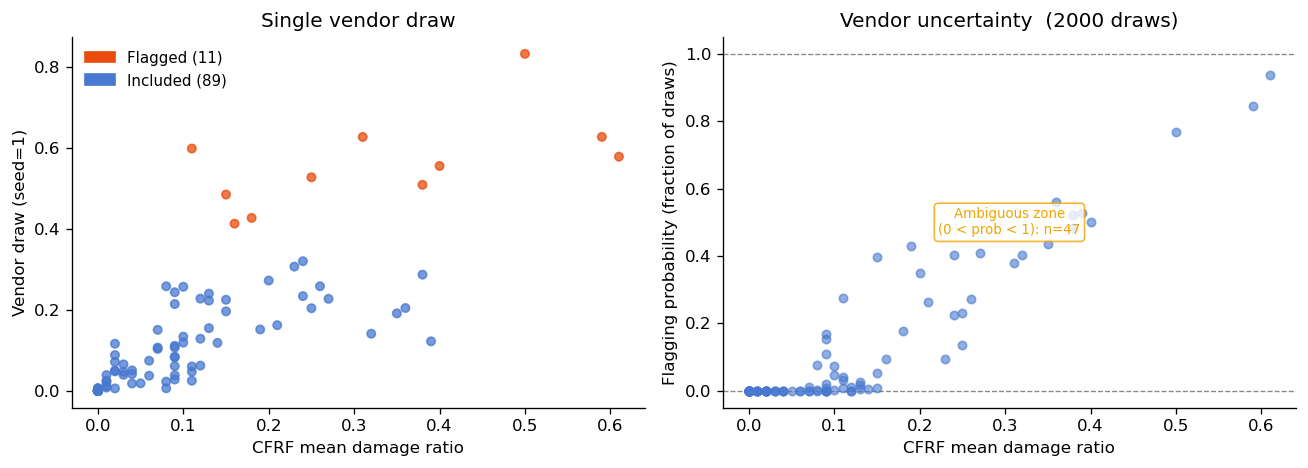

In [45]:
# Figure 1 — Damage ratio uncertainty vs. flagging probability
mean_d = results['d_mean'].values

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: single vendor draw
ax = axes[0]
colours_sv = np.where(flagged_v, RED, BLUE)
ax.scatter(mean_d, d_v, c=colours_sv, s=25, alpha=0.75, zorder=3)
ax.set_xlabel('CFRF mean damage ratio')
ax.set_ylabel(f'Vendor draw (seed={VENDOR_SEED})')
ax.set_title('Single vendor draw')
ax.legend(handles=[
    mpatches.Patch(color=RED,  label=f'Flagged ({n_flagged_v})'),
    mpatches.Patch(color=BLUE, label=f'Included ({N_ISSUERS - n_flagged_v})'),
], frameon=False, fontsize=9)

# Right: flagging probability across N_DRAWS
ax = axes[1]
n_ambiguous = ambiguous.sum()
ax.scatter(mean_d, inclusion_prob, c=BLUE, s=25, alpha=0.6, zorder=3)
ax.axhline(0.0, color=GREY, linewidth=0.8, linestyle='--')
ax.axhline(1.0, color=GREY, linewidth=0.8, linestyle='--')
ax.set_xlabel('CFRF mean damage ratio')
ax.set_ylabel('Flagging probability (fraction of draws)')
ax.set_title(f'Vendor uncertainty  ({N_DRAWS} draws)')
ax.annotate(
    f'Ambiguous zone\n(0 < prob < 1): n={n_ambiguous}',
    xy=(mean_d.max() * 0.5, 0.5),
    fontsize=8, color=AMBER,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=AMBER, alpha=0.8)
)

plt.tight_layout()
plt.show()

## Figure 2 — Rank instability across vendor draws

Rank instability is measured as the standard deviation of an issuer's percentile rank across all vendor draws. Issuers are classified by their flagging regime: those never reaching the threshold (grey), those sometimes crossing it (amber), and those always flagged (red). Issuers in the amber category are most consequential for portfolio construction, as their inclusion depends entirely on vendor choice.

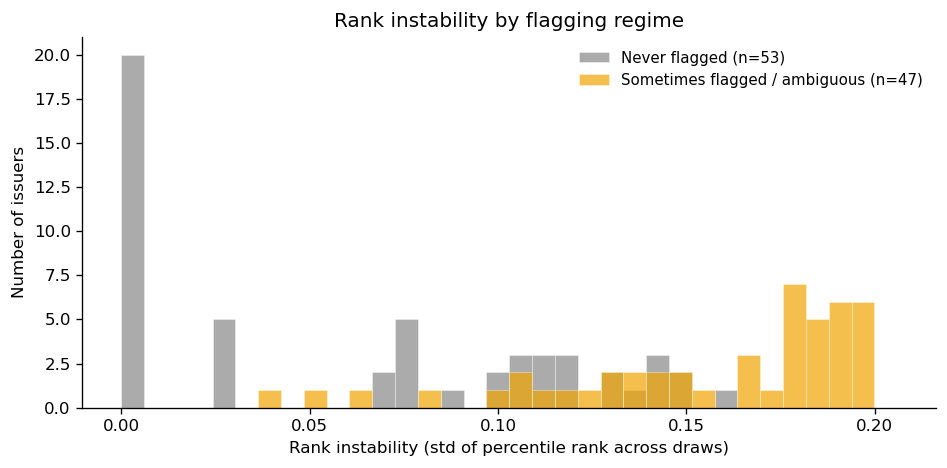

In [46]:
# Figure 2 — Rank instability histogram by flagging regime
fig, ax = plt.subplots(figsize=(8, 4))

bins = np.linspace(0, rank_instability.max() * 1.05, 35)

for mask, col, label in [
    (never_flagged,   GREY,  f'Never flagged (n={never_flagged.sum()})'),
    (ambiguous,       AMBER, f'Sometimes flagged / ambiguous (n={ambiguous.sum()})'),
    (always_flagged,  RED,   f'Always flagged (n={always_flagged.sum()})'),
]:
    if mask.sum() > 0:
        ax.hist(rank_instability[mask], bins=bins, color=col, alpha=0.7,
                edgecolor='white', linewidth=0.3, label=label)

ax.set_xlabel('Rank instability (std of percentile rank across draws)')
ax.set_ylabel('Number of issuers')
ax.set_title('Rank instability by flagging regime')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## Figure 3 — Flagging probability sorted by mean damage ratio

Each bar represents one issuer, sorted by the CFRF mean damage ratio (the empirical ordering). Bar height gives the issuer's flagging probability across N_DRAWS vendor simulations. Amber bars identify issuers in the ambiguous zone where vendor choice is decisive. This is the Decision 4 analogue of the staging instability chart in Decision 1: it shows that vendor disagreement creates a cliff zone near the rank threshold where portfolio inclusion is essentially arbitrary.

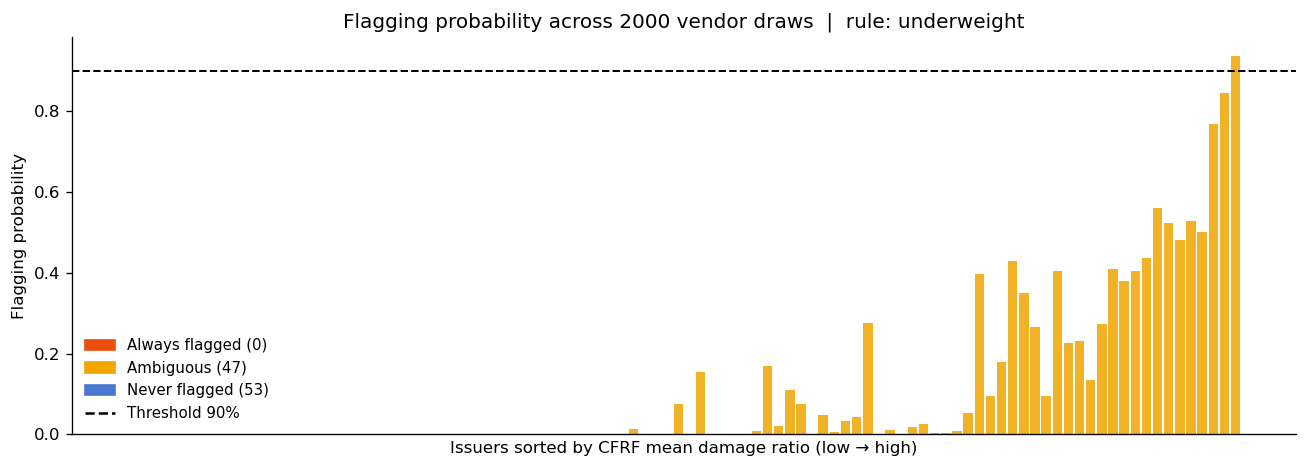

In [47]:
# Figure 3 — Flagging probability bar chart sorted by mean damage ratio
sort_idx = np.argsort(mean_d)
x_pos    = np.arange(N_ISSUERS)

bar_colours = np.where(
    always_flagged[sort_idx], RED,
    np.where(ambiguous[sort_idx], AMBER, BLUE)
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x_pos, inclusion_prob[sort_idx], color=bar_colours, width=0.85, alpha=0.85)
ax.axhline(THRESHOLD, color='black', linewidth=1.2, linestyle='--',
           label=f'Threshold  τ = {THRESHOLD:.0%}')
ax.set_xlabel('Issuers sorted by CFRF mean damage ratio (low → high)')
ax.set_ylabel('Flagging probability')
ax.set_title(f'Flagging probability across {N_DRAWS} vendor draws  |  rule: {RULE}')
ax.set_xticks([])
ax.legend(
    handles=[
        mpatches.Patch(color=RED,   label=f'Always flagged ({always_flagged.sum()})'),
        mpatches.Patch(color=AMBER, label=f'Ambiguous ({ambiguous.sum()})'),
        mpatches.Patch(color=BLUE,  label=f'Never flagged ({never_flagged.sum()})'),
        plt.Line2D([0],[0], color='black', linestyle='--',
                   label=f'Threshold {THRESHOLD:.0%}'),
    ],
    frameon=False, fontsize=9
)
plt.tight_layout()
plt.show()

## Figure 4 — Active weight dispersion across vendor draws

The boxplot shows the distribution of active weight deviations (w_active − w_benchmark) across all N_DRAWS for the 20 most variable issuers. Issuers receiving positive active weight (overweight relative to benchmark) are shown in blue; those receiving negative active weight (underweight or excluded) in red. The horizontal dashed line at zero is the benchmark allocation.

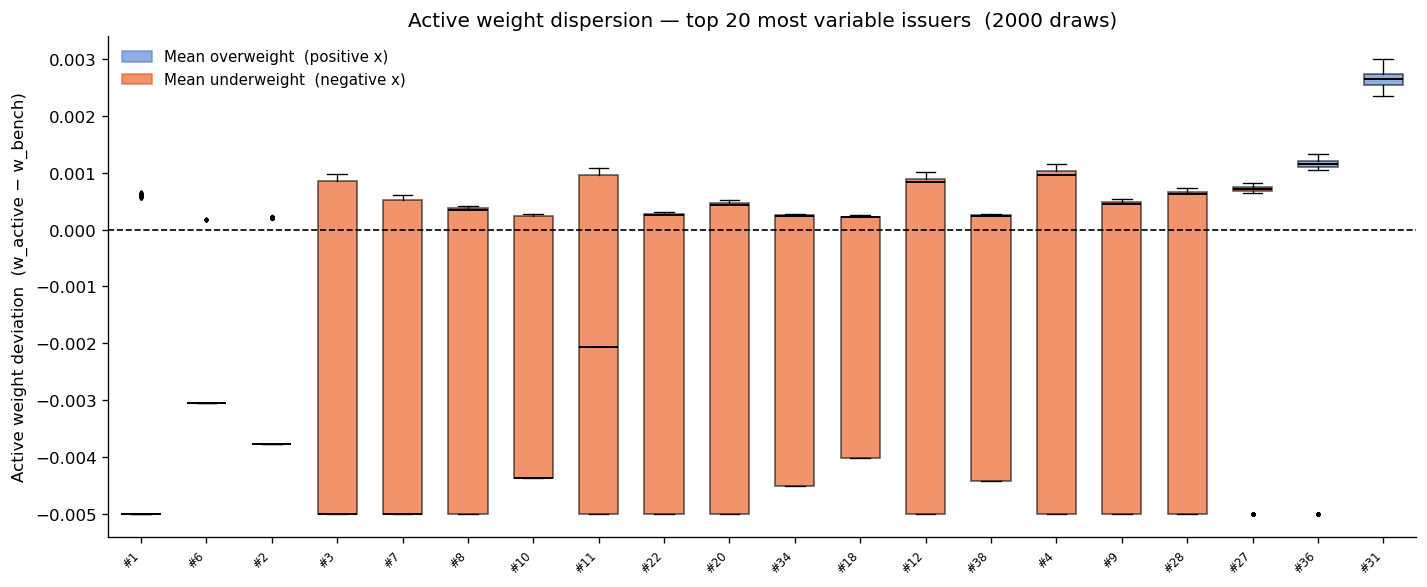

In [48]:
# Figure 4 — Active weight dispersion: top 20 most variable issuers
mean_abs_x = np.abs(x_matrix).mean(axis=0)
top20_idx  = np.argsort(mean_abs_x)[::-1][:20]
# Sort top-20 by mean active weight (negative first, then positive)
mean_x_top20 = x_matrix[:, top20_idx].mean(axis=0)
order_top20  = np.argsort(mean_x_top20)
plot_idx     = top20_idx[order_top20]

box_data = [x_matrix[:, i] for i in plot_idx]
box_means = np.array([d.mean() for d in box_data])

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(
    box_data,
    positions=np.arange(len(plot_idx)),
    widths=0.6,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.2),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
)

for patch, mean_val in zip(bp['boxes'], box_means):
    patch.set_facecolor(BLUE if mean_val >= 0 else RED)
    patch.set_alpha(0.6)

ax.axhline(0, color='black', linewidth=1.0, linestyle='--')
ax.set_xticks(np.arange(len(plot_idx)))
ax.set_xticklabels(
    [f'#{results["property_rank"].values[i]}' for i in plot_idx],
    rotation=45, ha='right', fontsize=7
)
ax.set_ylabel('Active weight deviation  (w_active − w_bench)')
ax.set_title(f'Active weight dispersion — top 20 most variable issuers  ({N_DRAWS} draws)')
ax.legend(handles=[
    mpatches.Patch(color=BLUE, alpha=0.6, label='Mean overweight  (positive x)'),
    mpatches.Patch(color=RED,  alpha=0.6, label='Mean underweight  (negative x)'),
], frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## Figure 5 — Tracking error distribution across vendor draws

The histogram shows the distribution of annualised tracking error across all N_DRAWS vendor simulations under the one-factor covariance model. The vertical line marks the tracking error for the single-vendor draw (VENDOR_SEED). The spread of the distribution quantifies how much the portfolio's risk budget relative to benchmark varies with vendor choice — a measure of the operational uncertainty introduced by model selection.

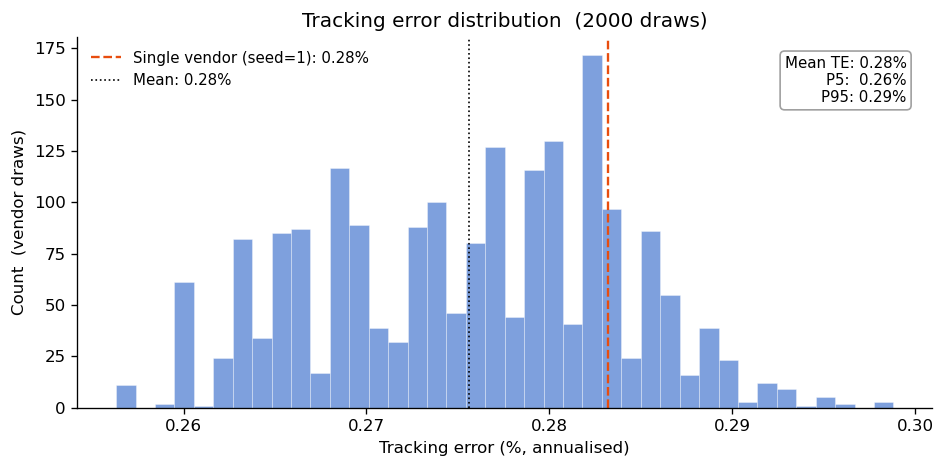

In [49]:
# Figure 5 — Tracking error or active share distribution
fig, ax = plt.subplots(figsize=(8, 4))

if COVARIANCE_MODE == 'one_factor':
    te_pct   = te_arr * 100
    te_v_pct = te_v   * 100

    te_range = te_pct.max() - te_pct.min()
    if te_range < 1e-8:
        # Degenerate: TE is constant across all draws (equal weights + fixed n_flagged).
        # Plot a spike at the single value instead of a histogram.
        ax.axvline(te_pct.mean(), color=BLUE, lw=3, alpha=0.8,
                   label=f'TE = {te_pct.mean():.3f}% (constant across all draws)')
        ax.set_xlim(te_pct.mean() - 0.5, te_pct.mean() + 0.5)
        ax.set_ylim(0, 1)
        ax.text(0.5, 0.5,
                f'TE is constant at {te_pct.mean():.3f}%\n'
                f'(equal benchmark weights → same active weight\n'
                f' magnitude every draw; use heterogeneous weights\n'
                f' or underweight rule for TE dispersion)',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=9, color=GREY,
                bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=GREY, alpha=0.8))
    else:
        n_bins = min(40, max(10, int(len(te_pct) ** 0.5)))
        ax.hist(te_pct, bins=n_bins, color=BLUE, alpha=0.7,
                edgecolor='white', linewidth=0.3)
        ax.axvline(te_v_pct, color=RED, linewidth=1.4, linestyle='--',
                   label=f'Single vendor (seed={VENDOR_SEED}): {te_v_pct:.2f}%')
        ax.axvline(np.mean(te_pct), color='black', linewidth=1.0, linestyle=':',
                   label=f'Mean: {np.mean(te_pct):.2f}%')
        ax.annotate(
            f'Mean TE: {np.mean(te_pct):.2f}%\n'
            f'P5:  {np.percentile(te_pct,  5):.2f}%\n'
            f'P95: {np.percentile(te_pct, 95):.2f}%',
            xy=(0.97, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=GREY, alpha=0.8)
        )

    ax.set_xlabel('Tracking error (%, annualised)')
    ax.set_ylabel(f'Count  (vendor draws)')
    ax.set_title(f'Tracking error distribution  ({N_DRAWS} draws)')

else:
    # COVARIANCE_MODE == 'none': plot active share = 0.5 * sum(|x|)
    active_share_arr = np.abs(x_matrix).sum(axis=1) / 2.0
    active_share_v_  = np.abs(x_v).sum() / 2.0
    as_range = active_share_arr.max() - active_share_arr.min()
    n_bins = min(40, max(10, int(len(active_share_arr) ** 0.5))) if as_range > 1e-8 else 1
    ax.hist(active_share_arr * 100, bins=n_bins, color=BLUE, alpha=0.7,
            edgecolor='white', linewidth=0.3)
    ax.axvline(active_share_v_ * 100, color=RED, linewidth=1.4, linestyle='--',
               label=f'Single vendor (seed={VENDOR_SEED}): {active_share_v_*100:.2f}%')
    ax.set_xlabel('Active share (%)')
    ax.set_ylabel('Count (vendor draws)')
    ax.set_title(f'Active share distribution  ({N_DRAWS} draws)')

ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


## Figure 6 — Vendor A vs. Vendor B: issuer-level disagreement

The pairwise comparison contrasts two specific vendor realisations (VENDOR_A and VENDOR_B). The scatter plot of percentile ranks reveals where the two vendors agree (both flag or both include) and where they disagree. The bar chart of absolute active weight differences identifies the issuers most sensitive to vendor selection. Together these panels illustrate the practical consequence of vendor model choice at the position level.

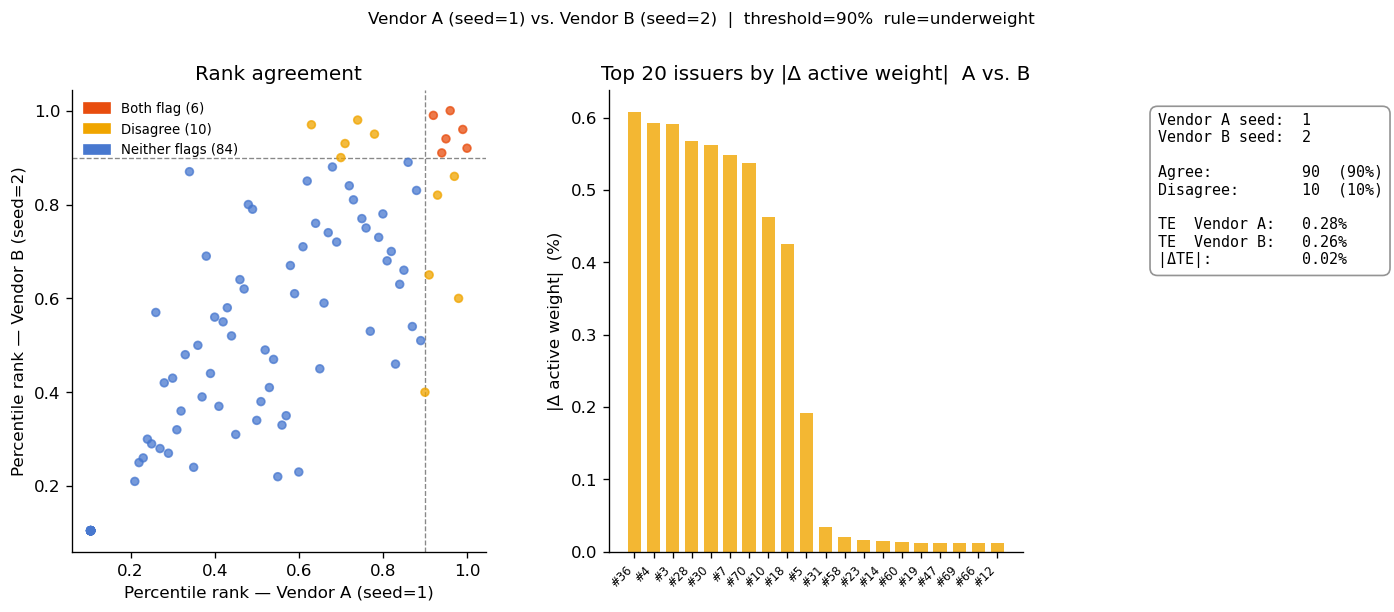

In [50]:
# Figure 6 — Vendor A vs. Vendor B pairwise comparison
rng_A = np.random.default_rng(VENDOR_A)
rng_B = np.random.default_rng(VENDOR_B)

d_A = sample_damage(rng_A)
d_B = sample_damage(rng_B)
r_A = rank_issuers(d_A)
r_B = rank_issuers(d_B)
w_A, x_A = apply_rule(w_bench, r_A, THRESHOLD, RULE, DELTA)
w_B, x_B = apply_rule(w_bench, r_B, THRESHOLD, RULE, DELTA)

flag_A = r_A >= THRESHOLD
flag_B = r_B >= THRESHOLD

both_flag    = flag_A & flag_B
neither_flag = (~flag_A) & (~flag_B)
disagree     = flag_A ^ flag_B

n_agree    = int(both_flag.sum() + neither_flag.sum())
n_disagree = int(disagree.sum())
disagree_rate = n_disagree / N_ISSUERS * 100

x_diff = np.abs(x_A - x_B)
top20_diff_idx = np.argsort(x_diff)[::-1][:20]

if COVARIANCE_MODE == 'one_factor':
    te_A = tracking_error(x_A, ASSET_VOL, FACTOR_RHO)
    te_B = tracking_error(x_B, ASSET_VOL, FACTOR_RHO)
    delta_te = abs(te_A - te_B)
else:
    delta_te = None

fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.55], wspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Panel 1: scatter of percentile ranks
scatter_colours = np.where(
    both_flag, RED,
    np.where(neither_flag, BLUE, AMBER)
)
ax1.scatter(r_A, r_B, c=scatter_colours, s=22, alpha=0.75, zorder=3)
ax1.axhline(THRESHOLD, color=GREY, linewidth=0.8, linestyle='--')
ax1.axvline(THRESHOLD, color=GREY, linewidth=0.8, linestyle='--')
ax1.set_xlabel(f'Percentile rank — Vendor A (seed={VENDOR_A})')
ax1.set_ylabel(f'Percentile rank — Vendor B (seed={VENDOR_B})')
ax1.set_title('Rank agreement')
ax1.legend(handles=[
    mpatches.Patch(color=RED,   label=f'Both flag ({both_flag.sum()})'),
    mpatches.Patch(color=AMBER, label=f'Disagree ({n_disagree})'),
    mpatches.Patch(color=BLUE,  label=f'Neither flags ({neither_flag.sum()})'),
], frameon=False, fontsize=8, loc='upper left')

# Panel 2: |Δ active weight| top 20
ax2.bar(
    np.arange(20), x_diff[top20_diff_idx] * 100,
    color=AMBER, alpha=0.8, width=0.7
)
ax2.set_xticks(np.arange(20))
ax2.set_xticklabels(
    [f'#{results["property_rank"].values[i]}' for i in top20_diff_idx],
    rotation=45, ha='right', fontsize=7
)
ax2.set_ylabel('|Δ active weight|  (%)')
ax2.set_title('Top 20 issuers by |Δ active weight|  A vs. B')

# Panel 3: annotation box
ax3.axis('off')
summary_lines = [
    f'Vendor A seed:  {VENDOR_A}',
    f'Vendor B seed:  {VENDOR_B}',
    '',
    f'Agree:          {n_agree}  ({n_agree/N_ISSUERS*100:.0f}%)',
    f'Disagree:       {n_disagree}  ({disagree_rate:.0f}%)',
]
if delta_te is not None:
    summary_lines += [
        '',
        f'TE  Vendor A:   {te_A*100:.2f}%',
        f'TE  Vendor B:   {te_B*100:.2f}%',
        f'|ΔTE|:          {delta_te*100:.2f}%',
    ]
ax3.text(
    0.05, 0.95, '\n'.join(summary_lines),
    transform=ax3.transAxes,
    va='top', ha='left', fontsize=9,
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=GREY, alpha=0.9)
)

plt.suptitle(
    f'Vendor A (seed={VENDOR_A}) vs. Vendor B (seed={VENDOR_B})  |  '
    f'threshold={THRESHOLD:.0%}  rule={RULE}',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()

## Figure 7 — Pairwise vendor disagreement across all draw pairs

The single-vendor and two-vendor comparisons above characterise specific draws. Here we quantify the full distribution of disagreement across all C(N_PAIR, 2) vendor pairs, using a subset of N_PAIR draws from the simulation.

**Left panel** — Distribution of the pairwise flagging disagreement rate: for each pair of vendor draws (i, j), the fraction of issuers where one vendor flags and the other does not. This directly measures the portfolio instability induced by vendor model selection.

**Right panel** — Distribution of pairwise |Δ tracking error|: the absolute difference in annualised TE between each pair of vendor draws. This quantifies how much the active risk budget varies with vendor choice — a portfolio manager selecting a different vendor would face a materially different TE constraint.

Together these panels are the Decision 4 analogue of the pairwise |Δ breach probability| charts in Decision 3: both show that two institutions using different vendors from the same benchmarking study will reach systematically different portfolio outcomes.

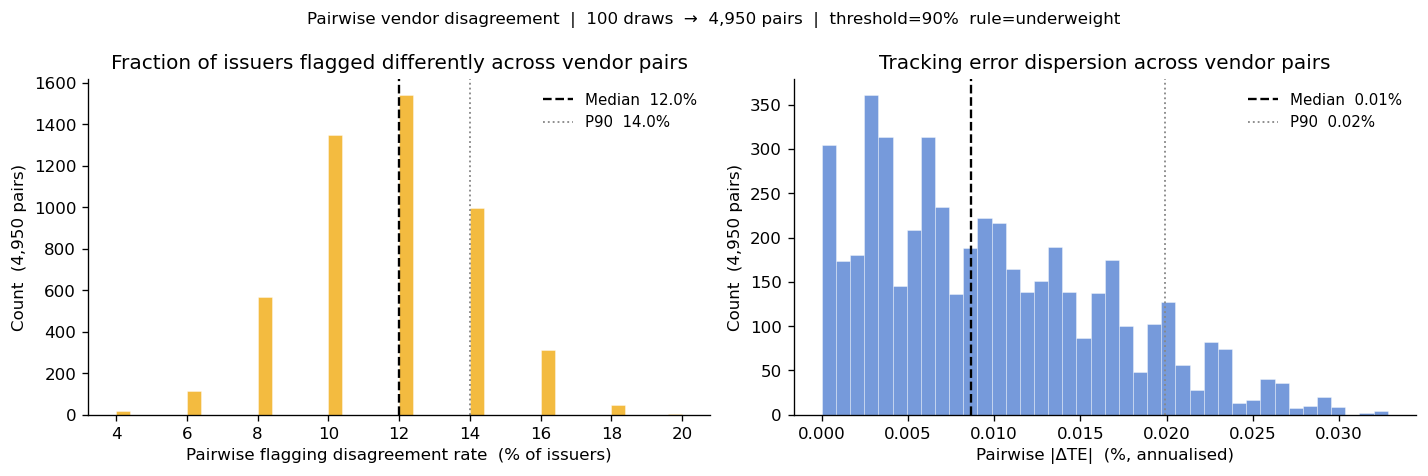


Pairwise disagreement summary  (4,950 vendor pairs)

  Metric                                             Median         P90         P95
  -----------------------------------------------------------------------------
  Flagging disagreement rate  (% issuers)            12.00%      14.00%      16.00%
  |Δ active share|                                  3.1950%     3.9304%     4.2817%
  |Δ tracking error|  (%)                           0.0087%     0.0199%     0.0229%


In [51]:
# =============================================================================
# PAIRWISE VENDOR DISAGREEMENT  (N_PAIR draws, C(N_PAIR,2) pairs)
# =============================================================================

# Use the first N_PAIR rows of the simulation matrices
flag_pair = flagged_matrix[:N_PAIR]   # (N_PAIR, N_ISSUERS)
x_pair    = x_matrix[:N_PAIR]         # (N_PAIR, N_ISSUERS)
te_pair   = te_arr[:N_PAIR]           # (N_PAIR,)

ii, jj  = np.triu_indices(N_PAIR, k=1)
n_pairs = len(ii)

# Pairwise flagging disagreement: fraction of issuers where exactly one vendor flags
disagree_pair = (flag_pair[ii] != flag_pair[jj]).mean(axis=1)   # (n_pairs,)

# Pairwise |Δ active share|: half the sum of absolute active-weight differences
active_share_diff = np.abs(x_pair[ii] - x_pair[jj]).sum(axis=1) / 2.0  # (n_pairs,)

# Pairwise |Δ TE|
te_diff_pair = np.abs(te_pair[ii] - te_pair[jj]) * 100   # (n_pairs,) in %

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: flagging disagreement rate ─────────────────────────────────────────
ax = axes[0]
ax.hist(disagree_pair * 100, bins=40, color=AMBER, alpha=0.75,
        edgecolor='white', linewidth=0.3)
ax.axvline(np.median(disagree_pair) * 100, color='black', lw=1.4, ls='--',
           label=f'Median  {np.median(disagree_pair)*100:.1f}%')
ax.axvline(np.percentile(disagree_pair, 90) * 100, color=GREY, lw=1.1, ls=':',
           label=f'P90  {np.percentile(disagree_pair, 90)*100:.1f}%')
ax.set_xlabel('Pairwise flagging disagreement rate  (% of issuers)')
ax.set_ylabel(f'Count  ({n_pairs:,} pairs)')
ax.set_title('Fraction of issuers flagged differently across vendor pairs')
ax.legend(frameon=False, fontsize=9)

# ── Right: |Δ TE| distribution ───────────────────────────────────────────────
ax = axes[1]
ax.hist(te_diff_pair, bins=40, color=BLUE, alpha=0.75,
        edgecolor='white', linewidth=0.3)
ax.axvline(np.median(te_diff_pair), color='black', lw=1.4, ls='--',
           label=f'Median  {np.median(te_diff_pair):.2f}%')
ax.axvline(np.percentile(te_diff_pair, 90), color=GREY, lw=1.1, ls=':',
           label=f'P90  {np.percentile(te_diff_pair, 90):.2f}%')
ax.set_xlabel('Pairwise |ΔTE|  (%, annualised)')
ax.set_ylabel(f'Count  ({n_pairs:,} pairs)')
ax.set_title('Tracking error dispersion across vendor pairs')
ax.legend(frameon=False, fontsize=9)

plt.suptitle(
    f'Pairwise vendor disagreement  |  {N_PAIR} draws  →  {n_pairs:,} pairs  |  '
    f'threshold={THRESHOLD:.0%}  rule={RULE}',
    fontsize=10
)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\nPairwise disagreement summary  ({n_pairs:,} vendor pairs)\n')
print(f'  {"Metric":<45s}  {"Median":>10}  {"P90":>10}  {"P95":>10}')
print('  ' + '-' * 77)
print(f'  {"Flagging disagreement rate  (% issuers)":<45s}  '
      f'{np.median(disagree_pair)*100:>9.2f}%  '
      f'{np.percentile(disagree_pair, 90)*100:>9.2f}%  '
      f'{np.percentile(disagree_pair, 95)*100:>9.2f}%')
print(f'  {"|Δ active share|":<45s}  '
      f'{np.median(active_share_diff)*100:>9.4f}%  '
      f'{np.percentile(active_share_diff, 90)*100:>9.4f}%  '
      f'{np.percentile(active_share_diff, 95)*100:>9.4f}%')
if COVARIANCE_MODE == 'one_factor':
    print(f'  {"|Δ tracking error|  (%)":<45s}  '
          f'{np.median(te_diff_pair):>9.4f}%  '
          f'{np.percentile(te_diff_pair, 90):>9.4f}%  '
          f'{np.percentile(te_diff_pair, 95):>9.4f}%')

In [53]:
# =============================================================================
# SUMMARY STATISTICS TABLE
# =============================================================================

te_pct_arr = te_arr * 100  if COVARIANCE_MODE == 'one_factor' else None
te_v_pct_  = te_v   * 100  if COVARIANCE_MODE == 'one_factor' else None
te_A_pct   = te_A   * 100  if COVARIANCE_MODE == 'one_factor' else None
te_B_pct   = te_B   * 100  if COVARIANCE_MODE == 'one_factor' else None

active_share_v_  = np.abs(x_v).sum() / 2.0
active_share_arr = np.abs(x_matrix).sum(axis=1) / 2.0

if COVARIANCE_MODE == 'one_factor':
    delta_te_val = abs(te_A - te_B) * 100
else:
    delta_te_val = float('nan')

def _fmt(v):
    if v == 'n/a' or (isinstance(v, float) and pd.isna(v)):
        return 'n/a'
    if isinstance(v, float):
        return f'{v:.4g}'
    return str(v)

sections = [
    ('Investable universe', {
        'N issuers':                          N_ISSUERS,
        'Benchmark weight mode':              WEIGHT_MODE,
        'Rank threshold  τ':                  f'{THRESHOLD:.0%}',
        'Portfolio rule':                     RULE,
    }),
    ('Single vendor draw  (VENDOR_SEED)', {
        'N flagged':                          int(n_flagged_v),
        '% of universe flagged':              f'{n_flagged_v/N_ISSUERS*100:.1f}%',
        'Active share  ½Σ|x|':                round(float(active_share_v_), 4),
        'Tracking error (%)':                 round(float(te_v_pct_), 4) if te_v_pct_ is not None else 'n/a',
    }),
    ('Vendor uncertainty — flagging instability', {
        'N issuers always flagged  (prob=1)':     int(always_flagged.sum()),
        'N issuers never flagged   (prob=0)':     int(never_flagged.sum()),
        'N issuers in ambiguous zone':            int(ambiguous.sum()),
        'Ambiguity rate  (% of universe)':        f'{ambiguous.mean()*100:.1f}%',
        'Mean rank instability — all issuers':    round(float(rank_instability.mean()), 4),
        'Mean rank instability — ambiguous zone': round(float(rank_instability[ambiguous].mean()), 4) if ambiguous.sum() > 0 else 'n/a',
    }),
    ('Vendor uncertainty — active weight / TE dispersion', {
        'Mean TE across draws (%)':    round(float(np.mean(te_pct_arr)), 4)           if te_pct_arr is not None else 'n/a',
        'Std  TE across draws (%)':    round(float(np.std(te_pct_arr)),  4)           if te_pct_arr is not None else 'n/a',
        'P5   TE (%)':                 round(float(np.percentile(te_pct_arr,  5)), 4) if te_pct_arr is not None else 'n/a',
        'P95  TE (%)':                 round(float(np.percentile(te_pct_arr, 95)), 4) if te_pct_arr is not None else 'n/a',
        'TE range  P95 − P5 (%)':      round(float(np.percentile(te_pct_arr, 95) - np.percentile(te_pct_arr, 5)), 4) if te_pct_arr is not None else 'n/a',
        'Mean active share':           round(float(active_share_arr.mean()), 4),
        'Std  active share':           round(float(active_share_arr.std()),  4),
    }),
    (f'Pairwise comparison  (A={VENDOR_A} vs. B={VENDOR_B})', {
        'N agree  (both flag or both include)': n_agree,
        'N disagree':                           n_disagree,
        'Disagreement rate (%)':                round(disagree_rate, 2),
        '|ΔTE|  (%)':                           round(float(delta_te_val), 4) if not pd.isna(delta_te_val) else 'n/a',
    }),
]

print(f'N vendor draws = {N_DRAWS}  |  Covariance mode: {COVARIANCE_MODE}\n')
for section_name, data in sections:
    print(f'\n--- {section_name} ---')
    for k, v in data.items():
        print(f'  {k:<52s}  {_fmt(v) if isinstance(v, float) else v}')

N vendor draws = 2000  |  Covariance mode: one_factor


--- Investable universe ---
  N issuers                                             100
  Benchmark weight mode                                 heterogeneous
  Rank threshold  τ                                     90%
  Portfolio rule                                        underweight

--- Single vendor draw  (VENDOR_SEED) ---
  N flagged                                             11
  % of universe flagged                                 11.0%
  Active share  ½Σ|x|                                   0.0513
  Tracking error (%)                                    0.2832

--- Vendor uncertainty — flagging instability ---
  N issuers always flagged  (prob=1)                    0
  N issuers never flagged   (prob=0)                    53
  N issuers in ambiguous zone                           47
  Ambiguity rate  (% of universe)                       47.0%
  Mean rank instability — all issuers                   0.1057
  Mean rank inst